--- AUC / GINI ---
Train: AUC=0.6788, Gini=0.3575
Test : AUC=0.7000, Gini=0.4000
OOT  : AUC=0.6975, Gini=0.3950

--- KOLMOGOROV-SMIRNOV (KS) ---
Train: 0.261
Test : 0.295
OOT  : 0.284


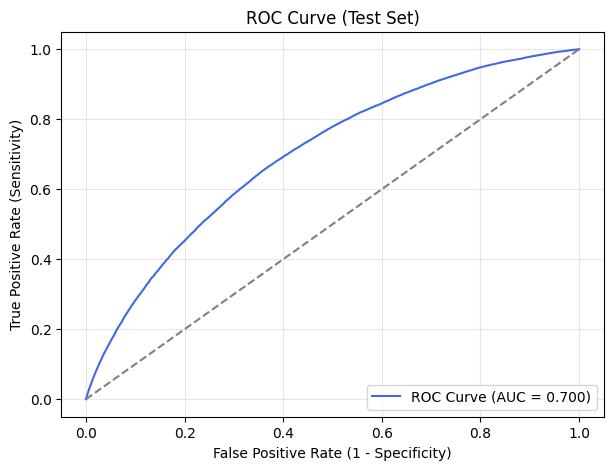


--- DECILE ANALYSIS TABLE (TEST) ---
 decile  total_accounts  bads  min_prob  max_prob  bad_rate     lift
      1           22147  9079  0.286320  0.541468  0.409943 2.211350
      2           22147  6832  0.236612  0.286320  0.308484 1.664054
      3           22147  5480  0.200881  0.236612  0.247438 1.334750
      4           22146  4830  0.171990  0.200881  0.218098 1.176484
      5           22147  3918  0.147951  0.171990  0.176909 0.954298
      6           22147  3358  0.123337  0.147951  0.151623 0.817900
      7           22146  2652  0.103431  0.123337  0.119751 0.645970
      8           22147  2236  0.081289  0.103431  0.100962 0.544617
      9           22147  1573  0.060035  0.081289  0.071025 0.383132
     10           22147  1098  0.027287  0.060035  0.049578 0.267437

--- CALIBRATION QUANTILE TABLE ---
                 bin  avg_predicted_pd  actual_bad_rate  volume
    (0.999, 22147.7]          0.047483         0.049578   22147
  (22147.7, 44294.4]          0.069195 

C:\Users\Harsh Prakash\AppData\Local\Temp\ipykernel_6764\1593086311.py:116: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return df.groupby('bin').agg(


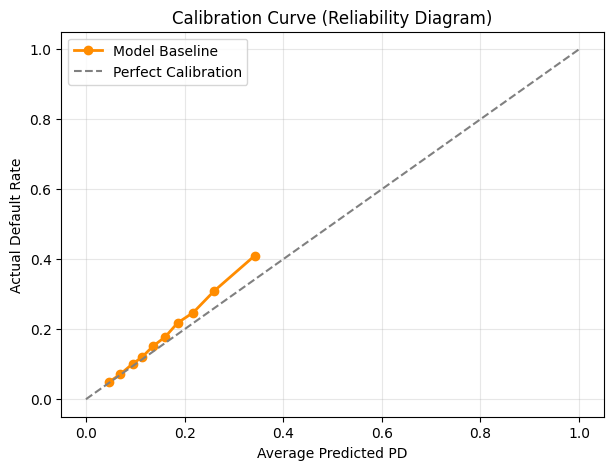

In [1]:
# =========================
# STAGE 4 — MODEL EVALUATION (FINAL)
# =========================

import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.calibration import calibration_curve

ARTIFACTS_PATH = r"C:\Users\Harsh Prakash\Desktop\Lending Club Credit Risk Project\artifacts"

# =========================
# LOAD & UNIFY DATA
# =========================

p_bad_train = pd.read_csv(os.path.join(ARTIFACTS_PATH, "pd_train.csv"))['pd']
p_bad_test  = pd.read_csv(os.path.join(ARTIFACTS_PATH, "pd_test.csv"))['pd']
p_bad_oot   = pd.read_csv(os.path.join(ARTIFACTS_PATH, "pd_oot.csv"))['pd']

# Unify target: Convert from (1=Good, 0=Bad) to Standard Risk Format (1=Bad, 0=Good)
y_train = 1 - pd.read_csv(os.path.join(ARTIFACTS_PATH, "y_train.csv")).squeeze()
y_test  = 1 - pd.read_csv(os.path.join(ARTIFACTS_PATH, "y_test.csv")).squeeze()
y_oot   = 1 - pd.read_csv(os.path.join(ARTIFACTS_PATH, "y_oot.csv")).squeeze()

# =========================
# 1. AUC / GINI
# =========================

def evaluate_auc(y, p_hat):
    # Standardized: y is already 1=Bad
    auc = roc_auc_score(y, p_hat)
    gini = 2 * auc - 1
    return auc, gini

print("--- AUC / GINI ---")
for name, y, p in [
    ("Train", y_train, p_bad_train),
    ("Test", y_test, p_bad_test),
    ("OOT", y_oot, p_bad_oot)
]:
    auc, gini = evaluate_auc(y, p)
    print(f"{name:<5}: AUC={auc:.4f}, Gini={gini:.4f}")

# =========================
# 2. KS STATISTIC
# =========================

def ks_stat(y, p_hat):
    df = pd.DataFrame({'y': y, 'p': p_hat}).sort_values('p', ascending=False)
    # y=1 is Bad, y=0 is Good
    df['cum_bad'] = (df['y'] == 1).cumsum() / (df['y'] == 1).sum()
    df['cum_good'] = (df['y'] == 0).cumsum() / (df['y'] == 0).sum()
    return np.max(np.abs(df['cum_bad'] - df['cum_good']))

print("\n--- KOLMOGOROV-SMIRNOV (KS) ---")
print(f"Train: {ks_stat(y_train, p_bad_train):.3f}")
print(f"Test : {ks_stat(y_test, p_bad_test):.3f}")
print(f"OOT  : {ks_stat(y_oot, p_bad_oot):.3f}")

# =========================
# 3. ROC CURVE (TEST)
# =========================

fpr, tpr, _ = roc_curve(y_test, p_bad_test)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc_score(y_test, p_bad_test):.3f})", color='royalblue')
plt.plot([0,1], [0,1], linestyle='--', color='grey')
plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.title("ROC Curve (Test Set)")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

# =========================
# 4. DECILE ANALYSIS
# =========================

def decile_table(y, p_hat, n=10):
    df = pd.DataFrame({'y': y, 'p': p_hat})
    
    # Rank probabilities high-to-low (0 = highest risk, 9 = lowest risk)
    df['decile'] = pd.qcut(df['p'].rank(method='first'), n, labels=False)
    df['decile'] = n - df['decile']  # Invert so 1 is highest risk, 10 is lowest
    
    agg = df.groupby('decile').agg(
        total_accounts=('y', 'count'),
        bads=('y', 'sum'),
        min_prob=('p', 'min'),
        max_prob=('p', 'max')
    ).reset_index()

    agg['bad_rate'] = agg['bads'] / agg['total_accounts']
    
    # Calculate Lift metrics
    overall_bad_rate = df['y'].sum() / df['y'].count()
    agg['lift'] = agg['bad_rate'] / overall_bad_rate
    
    return agg.sort_values('decile')

print("\n--- DECILE ANALYSIS TABLE (TEST) ---")
print(decile_table(y_test, p_bad_test).to_string(index=False))

# =========================
# 5. CALIBRATION TABLE & CURVE
# =========================

def calibration_table(y, p_hat, bins=10):
    df = pd.DataFrame({'y': y, 'p': p_hat})
    df['bin'] = pd.qcut(df['p'].rank(method='first'), bins)

    return df.groupby('bin').agg(
        avg_predicted_pd=('p', 'mean'),
        actual_bad_rate=('y', 'mean'),
        volume=('y', 'count')
    ).reset_index()

print("\n--- CALIBRATION QUANTILE TABLE ---")
print(calibration_table(y_test, p_bad_test).to_string(index=False))

# Plot Calibration Curve
prob_true, prob_pred = calibration_curve(y_test, p_bad_test, n_bins=10, strategy='quantile')

plt.figure(figsize=(7, 5))
plt.plot(prob_pred, prob_true, marker='o', linewidth=2, label='Model Baseline', color='darkorange')
plt.plot([0,1], [0,1], '--', color='grey', label='Perfect Calibration')
plt.xlabel("Average Predicted PD")
plt.ylabel("Actual Default Rate")
plt.title("Calibration Curve (Reliability Diagram)")
plt.legend(loc="upper left")
plt.grid(True, alpha=0.3)
plt.show()

In [2]:
# =========================
# 7. HOSMER-LEMESHOW TEST
# =========================
from scipy.stats import chi2

def hosmer_lemeshow_test(y, p_hat, bins=10):
    """
    Computes the formal Hosmer-Lemeshow goodness-of-fit test.
    Assumes unified target format: y (1=Bad, 0=Good)
    """
    df = pd.DataFrame({'y': y, 'p': p_hat})
    # Force clean equal-sized bins using rank to avoid duplicate edge drop issues
    df['bin'] = pd.qcut(df['p'].rank(method='first'), bins, labels=False)

    # Compute observed and expected totals for Bads (1) and Goods (0) per bin
    hl = df.groupby('bin').agg(
        obs_bad=('y', 'sum'),
        total=('y', 'count'),
        exp_p=('p', 'mean')
    ).reset_index()
    
    hl['obs_good'] = hl['total'] - hl['obs_bad']
    hl['exp_bad'] = hl['total'] * hl['exp_p']
    hl['exp_good'] = hl['total'] * (1 - hl['exp_p'])

    # Avoid zero division errors with a small epsilon
    eps = 1e-10
    
    # Chi-sq component for bads and goods
    hl['chi_bad'] = ((hl['obs_bad'] - hl['exp_bad']) ** 2) / (hl['exp_bad'] + eps)
    hl['chi_good'] = ((hl['obs_good'] - hl['exp_good']) ** 2) / (hl['exp_good'] + eps)
    
    hl_stat = hl['chi_bad'].sum() + hl['chi_good'].sum()
    
    # Degrees of freedom = bins - 2
    df_degrees = bins - 2
    p_value = 1 - chi2.cdf(hl_stat, df_degrees)
    
    return hl_stat, p_value

# Run HL Test using the unified y_test (1=Bad)
hl_stat, hl_p = hosmer_lemeshow_test(y_test, p_bad_test, bins=10)

print("\n--- HOSMER-LEMESHOW GOODNESS-OF-FIT ---")
print(f"HL Statistic : {hl_stat:.2f}")
print(f"HL p-value   : {hl_p:.4f} (Low p-value indicates calibration mismatch)")


# =========================
# 8. LGD EVALUATION
# =========================

print("\n--- LGD EVALUATION ---")
try:
    # Ensure artifacts exist before processing
    lgd_pred_path = os.path.join(ARTIFACTS_PATH, "lgd_pred_test.csv")
    y_lgd_path = os.path.join(ARTIFACTS_PATH, "y_lgd_test.csv")
    
    if os.path.exists(lgd_pred_path) and os.path.exists(y_lgd_path):
        lgd_pred = pd.read_csv(lgd_pred_path).squeeze()
        y_lgd = pd.read_csv(y_lgd_path).squeeze()

        # Calculation Metrics
        mae = np.mean(np.abs(y_lgd - lgd_pred))
        rmse = np.sqrt(mean_squared_error(y_lgd, lgd_pred))

        print(f"MAE  : {mae:.4f}")
        print(f"RMSE : {rmse:.4f}")
    else:
        print("LGD prediction data files missing in artifacts — using Stage 3 default outputs.")
except Exception as e:
    print(f"LGD Evaluation failed to execute: {str(e)}")


# =========================
# 9. EAD NOTE
# =========================

print("\n--- EAD MODEL ---")
print("EAD Assumption : Funded Amount (Standard fixed-term loan architecture)")
print("Framework      : No predictive conversion factor (CCF) modeling needed → Metrics not applicable")


# =========================
# 10. STABILITY CHECK
# =========================

# Evaluate standardized metrics (y is already transformed to 1=Bad)
auc_tr, gini_tr = evaluate_auc(y_train, p_bad_train)
auc_te, gini_te = evaluate_auc(y_test, p_bad_test)
auc_oot, gini_oot = evaluate_auc(y_oot, p_bad_oot)

print("\n--- STABILITY & RISK DRIFT ANALYSIS ---")
print(f"Gini Drop (Train → Test) : {gini_tr - gini_te:.4f}")
print(f"Gini Drop (Test → OOT)   : {gini_te - gini_oot:.4f}")

# Sanity warning for drift threshold check
if (gini_te - gini_oot) > 0.05:
    print("⚠️ WARNING: Gini drop between Test and OOT exceeds 5%. Check for population or macroeconomic shift.")
elif (gini_tr - gini_te) > 0.05:
    print("⚠️ WARNING: High training variance detected. Model may be overfitted.")
else:
    print("✅ Performance drops are within acceptable institutional parameters (< 5%).")

print("\n✅ STAGE 4 COMPLETE — MODEL VALIDATED AND READY FOR DEPLOYMENT ANALYSIS")


--- HOSMER-LEMESHOW GOODNESS-OF-FIT ---
HL Statistic : 1118.14
HL p-value   : 0.0000 (Low p-value indicates calibration mismatch)

--- LGD EVALUATION ---
LGD prediction data files missing in artifacts — using Stage 3 default outputs.

--- EAD MODEL ---
EAD Assumption : Funded Amount (Standard fixed-term loan architecture)
Framework      : No predictive conversion factor (CCF) modeling needed → Metrics not applicable

--- STABILITY & RISK DRIFT ANALYSIS ---
Gini Drop (Train → Test) : -0.0425
Gini Drop (Test → OOT)   : 0.0050
✅ Performance drops are within acceptable institutional parameters (< 5%).

✅ STAGE 4 COMPLETE — MODEL VALIDATED AND READY FOR DEPLOYMENT ANALYSIS
